In [1]:
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, "/home/world-models/lewm-cus")
from src.utils import load_model
from src.data import H5Reader, ImageTransform, get_normalizer, split_episodes
from src.models import latent_sq_dist


/root/miniconda3/envs/temporal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
CKPT = "/home/world-models/lewm-cus/checkpoints/observation_model/epoch_007.pt"   # LeWM: ViT-tiny from scratch
device = "cuda"
model, cfg = load_model(CKPT, device=device)
H, FS = cfg.data.history, cfg.data.frameskip   # 3 context frames, 5 env steps per latent step
HORIZON = 10                                   # latent steps to imagine = 50 env steps

reader = H5Reader(cfg.data.h5_path, rdcc_mb=cfg.data.rdcc_mb)
normalizer = get_normalizer(cfg, reader, (cfg.data.obs_key, "action"))   # reads the cached .stats.npz
transform = ImageTransform(cfg.data.img_size)
train_eps, val_eps = split_episodes(reader.num_episodes, cfg.data.val_episodes, cfg.seed, cfg.data.max_episodes)

STATE_COLS = ["privileged_block_0_pos", "proprio_effector_pos", "proprio_gripper_opening"]
NAMES = ["cube x", "cube y", "cube z", "ee x", "ee y", "ee z", "gripper"]
print(f"{cfg.model.encoder} encoder | {model.predictor.num_patches} tokens/frame | D={cfg.model.embed_dim}")


vit encoder | 1 tokens/frame | D=192


In [14]:
@torch.no_grad()
def load_episode(ep, keep_latents=True):
    """A whole episode at latent-step resolution: n+1 frames and n action blocks, encoded once."""
    start, length = int(reader.ep_offset[ep]), int(reader.ep_len[ep])
    n = (length - 1) // FS                                    # the last row's action is NaN
    stop = start + n * FS + 1
    obs = reader.span(cfg.data.obs_key, start, stop)[::FS].copy()                  # (n+1, ...)
    act = np.nan_to_num(reader.span("action", start, start + n * FS), nan=0.0)
    act = normalizer.normalize("action", act).astype(np.float32).reshape(n, -1)    # (n, FS*A), same as training
    state = np.concatenate([reader.span(c, start, stop)[::FS] for c in STATE_COLS], -1).astype(np.float32)

    if cfg.data.obs_key == "pixels":
        x = transform(obs)
    else:
        x = torch.from_numpy(normalizer.normalize(cfg.data.obs_key, obs).astype(np.float32))
    emb = model.encode(x[None].to(device))[0]                                      # (n+1, P, D)

    d = {"ep": int(ep), "state": torch.from_numpy(state)}
    if keep_latents:
        d.update(emb=emb.cpu(), act=torch.from_numpy(act), frames=obs if cfg.data.obs_key == "pixels" else None)
    else:
        d["feat"] = probe_features(emb).cpu()
    return d


val_data = load_episode(val_eps[0], keep_latents=True)

In [13]:
for key, val in data.items():
    if isinstance(val, torch.Tensor):
        print(f"{key}: {val.shape} | {val.dtype}")
    else:
        print(f"{key}: {type(val)}")

ep: <class 'int'>
state: torch.Size([41, 7]) | torch.float32
emb: torch.Size([41, 1, 192]) | torch.float32
act: torch.Size([40, 25]) | torch.float32
frames: <class 'numpy.ndarray'>


In [16]:
d = val_data
emb = d["emb"].to(device)   # (41, 1, 192)  frames 0..40
act = d["act"].to(device)   # (40, 25)      action block t takes frame t -> t+1
H = cfg.data.history        # 3

# roll out the whole episode: observe frames 0..2, then imagine frames 3..40 using the true actions
with torch.no_grad():
    pred = model.rollout(emb[None, :H], act[None])   # ctx (1, 3, 1, 192), actions (1, 40, 25)
pred = pred[0]                                       # (38, 1, 192)  = predictions of frames 3..40
target = emb[H:]                                     # (38, 1, 192)
err = latent_sq_dist(pred, target)                   # (38,)  error per step ahead


In [20]:
s, h = 10, 10
with torch.no_grad():
    pred = model.rollout(emb[None, s:s+H], act[None, s:s+H+h-1])[0]   # (h, 1, 192)
target = emb[s+H : s+H+h]                                             # (h, 1, 192)


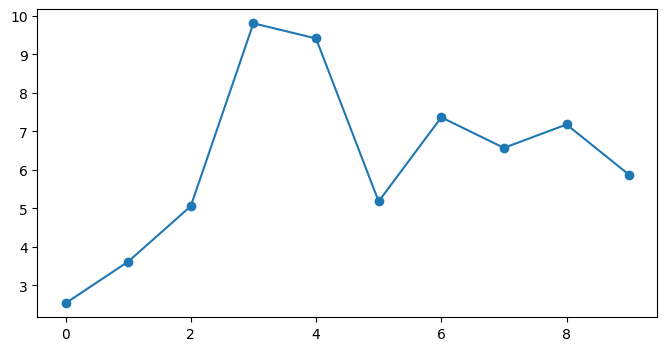

In [28]:
target.shape, pred.shape

error = latent_sq_dist(pred, target)   # (h,)  error per step ahead
plt.figure(figsize=(8, 4))
plt.plot(error.cpu().numpy(), marker="o")
# print(error.shape)

(41, 224, 224, 3)


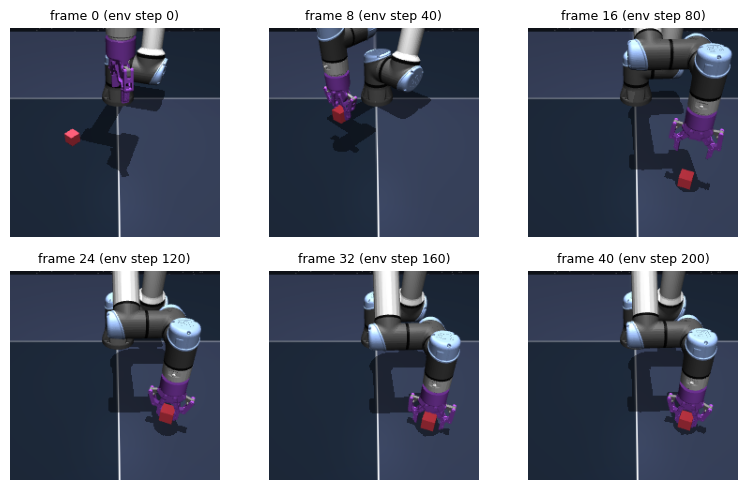

In [24]:
d = val_data
frames = d["frames"]            # (41, 224, 224, 3) uint8, one frame every 5 env steps
print(frames.shape)

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for k, a in enumerate(axes.flat):
    t = k * 8
    a.imshow(frames[t])
    a.set_title(f"frame {t} (env step {t * FS})", fontsize=9)
    a.axis("off")
fig.tight_layout()


Text(0.5, 1.0, 'Latent prediction error per step ahead | vit encoder | 1 tokens/frame | D=192')

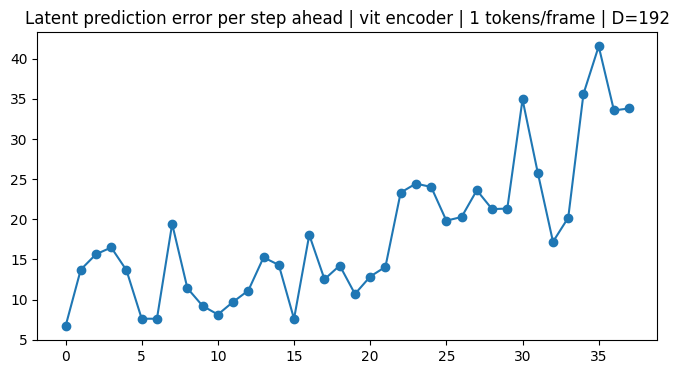

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(err.cpu().numpy(), marker="o")
plt.title(f"Latent prediction error per step ahead | {cfg.model.encoder} encoder | {model.predictor.num_patches} tokens/frame | D={cfg.model.embed_dim}")